# The Notebook for online PID for the Schottky spectrum (ion in isochronous mode)
Please follow the steps to get a reasonable PID result for your Schottky spectrum

## Get the peak information from the Schottky spectrum
1. The input data of the Schottky spectrum should be .npz file with 'arr_0' for absolute frequencies, 'arr_1' for magnitude
2. Peak information includes: 'peak_no' for index of peak, 'exp_freq' for absolute frequency of peak \[kHz], 'peak_width' for width of peak \[kHz], 'peak_height' for height of peak, 'delta_f_over_f' for peak width / 2 / sqrt(2 ln(2)) / frequency of peak. All these information is saved as .csv file.

0.0856943633557814
center frequency: 411.742 MHz
span: 50000.0 kHz
window length: 65536


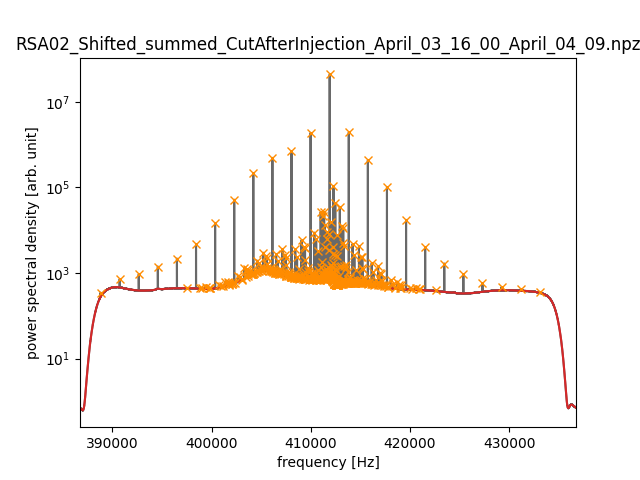

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
import pandas as pd

from nonparams_est import NONPARAMS_EST

%matplotlib ipympl

cen_freq = 410.535 # MHz

file_folder = "./"
file_strs = ["RSA02_Shifted_summed_CutAfterInjection_April_03_16_00_April_04_09.npz"]
peak_file = '188Hf.csv'
file_str = file_strs[-1]
f = np.load(file_folder+file_str)
frequencies = f['arr_0']/1e3 # kHz
_psd = f['arr_1']

nonparas_base = NONPARAMS_EST(_psd)
# method for baseline estimation, l is for the smoothness, if l is larger, the smoother of the estimated baseline
# more information can be found at doi: 10.1007/s41365-022-01132-9 & https://github.com/NanaVan/baseline-estimate
base_BrPLS = nonparas_base.pls(method='BrPLS', l=10**6, ratio=1e-6)

# method for find peaks, more information can be found at https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html
#peaks, properties = find_peaks(_psd-base_BrPLS, height=1e-1, width=1)
#peaks, properties = find_peaks(_psd-base_BrPLS, height=1, width=1)
peaks, properties = find_peaks(_psd-base_BrPLS, height=10, width=1)
#print(properties)

fig, ax = plt.subplots()
ax.set_title(file_str)
ax.set_yscale('log')
ax.plot(frequencies, _psd, color='dimgray')
ax.plot(frequencies, base_BrPLS, color='tab:red')
ax.plot(frequencies[peaks], _psd[peaks], 'x', color='darkorange')
ax.set_xlim([frequencies[0], frequencies[-1]])
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("power spectral density [arb. unit]")
cen_freq = (frequencies[0]+frequencies[-1])/2e3 # MHz
win_len = len(frequencies)
span = np.round(frequencies[-1]-frequencies[0])+1 # kHz
print('center frequency: {:g} MHz'.format(cen_freq))
print('span: {:} kHz'.format(span))
print('window length: {:g}'.format(win_len))

pd.DataFrame({'peak_no': np.arange(len(peaks)), 'exp_freq': frequencies[peaks], 'peak_width': properties['widths']*(frequencies[1]-frequencies[0]), 'peak_height': properties['peak_heights'], 'delta_f_over_f': properties['widths']*(frequencies[1]-frequencies[0])/2/np.sqrt(2*np.log(2))/frequencies[peaks]}).to_csv(file_folder+peak_file, index=False)

plt.show()

## Get a reasonable PID result
1. A proper .lpp file is needed, which means the .lpp file should include all the possible ion species.
2. A proper initial orbit length is also needed.
3. If the proper Brho is known, the sweep program runtime can be reduced.

In [2]:
from sweep_iid import SWEEP_IID

gamma_t = 1.4
initial_orbit_len = 108.34 # [m]
L_range = [108.25, 108.58, 40]
lise_file = 'New_TEline2022-ESR-188Hf-208Pb-nostripper_509MeV-v2.lpp'

sw_0 = SWEEP_IID(file_folder+peak_file, file_folder+lise_file, cen_freq, span, win_len, gamma_t, initial_orbit_len)
pid_loop = sw_0.calibrate_global(init_Brho=7.9183, delta_Brho=0.001, L_range=L_range, save_PID_dataframe=True)

iid: initial...
iid: initial complete
sweep peaks number in spec: 182
peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9192962 Tm, C: 108.3471, skip num: 138, included num: 44
ChiSqr: 4.18529, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.09733241986978905, Additional_ReChiSqr: 0.9574372954546811
peakloc: 169.75, id: 208Tl79(0), harmonic: 214, Brho: 7.9184632 Tm, C: 108.3399, skip num: 165, included num: 17
ChiSqr: 10.48482, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.6553012561566496, Additional_ReChiSqr: 61.7320993040304
peakloc: 169.75, id: 7Li3(0), harmonic: 202, Brho: 7.9198243 Tm, C: 108.3401, skip num: 178, included num: 4
ChiSqr: 1.00541, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.33513502764313724, Additional_ReChiSqr: 663.6511384903225
peakloc: 169.75, id: 193Os74(0), harmonic: 213, Brho: 7.9148385 Tm, C: 108.3398, skip num: 167, included num: 15
ChiSqr: 74.82023, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 5.344302146589638, Additional_ReChiSqr: 662.4321891832818
pea

The line search decreased the step size to within tolerance specified by AccuracyGoal and PrecisionGoal but was unable to find a sufficient decrease in the merit function. You may need more than MachinePrecision digits of working precision to meet these tolerances.
The line search decreased the step size to within tolerance specified by AccuracyGoal and PrecisionGoal but was unable to find a sufficient decrease in the merit function. You may need more than MachinePrecision digits of working precision to meet these tolerances.


peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9057974 Tm, C: 108.2517
ChiSqr: 7.90231, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.23242089527996146, Additional_ReChiSqr: 4.09990459273852
peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9088977 Tm, C: 108.2736
ChiSqr: 13.27117, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.4021565353113834, Additional_ReChiSqr: 7.62010099434303
peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9093037 Tm, C: 108.2764
ChiSqr: 11.84738, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.3702305512704773, Additional_ReChiSqr: 7.547739640730825
peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9093128 Tm, C: 108.2765
ChiSqr: 12.04681, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.38860672174902444, Additional_ReChiSqr: 8.538721913430713
peakloc: 169.75, id: 208Pb79(0), harmonic: 214, Brho: 7.9117789 Tm, C: 108.2939
ChiSqr: 16.09092, A>0: True, AC-B^2>0: True, Reduced_ChiSqr: 0.5190618112312061, Additional_ReChiSqr: 11.40516675068568
p

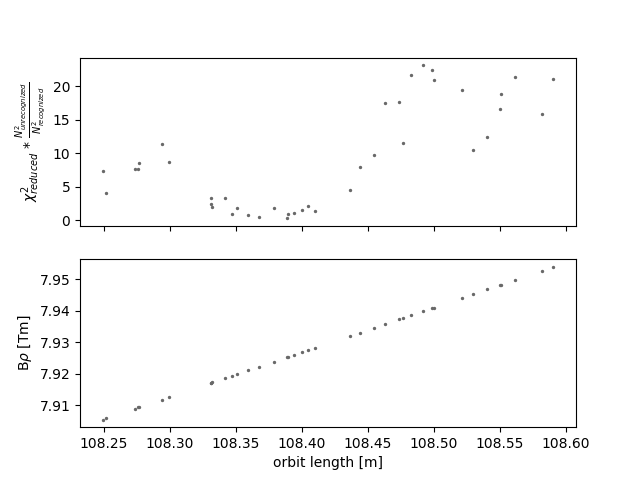

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib ipympl

pid_loop.sort_values(['C_est'], ascending=True, inplace=True)

L_range_init, y_range_init, Brho_range_init  = pid_loop['C_est'].values, pid_loop['addition_chisqr'].values, pid_loop['Brho_est'].values

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].scatter(L_range_init, y_range_init, s=2, color='dimgray')
ax[1].scatter(L_range_init, Brho_range_init, s=2, color='dimgray')
ax[1].set_xlabel("orbit length [m]")
ax[1].set_ylabel(r"B$\rho$ [Tm]")
ax[0].set_ylabel(r"$\chi^{2}_{reduced}$ * $\frac{N^{2}_{unrecognized}}{N^{2}_{recognized}}$")
plt.show()

fit: 1560.555502 x^2 -338248.166754 x + 18328701.652184
estimated L = 108.374283 [m]


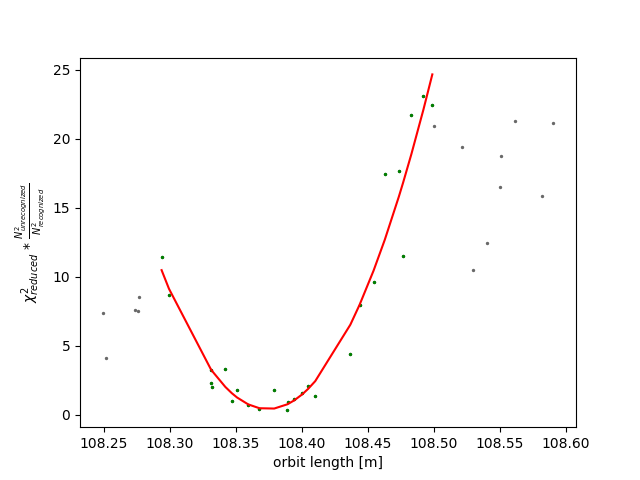

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit 
import pandas as pd

%matplotlib ipympl

# fitting y-L curve 
def parabola_func(x, a, b, c):
    return a*x**2 + b*x + c

# check the L range for a proper parabola-like y-L curve
ind_0 = np.searchsorted(L_range_init, 108.28, side='left')
ind_1 = np.searchsorted(L_range_init, 108.5, side='left')
_x, _y = L_range_init[ind_0:ind_1], y_range_init[ind_0:ind_1]
parabola_para, parabola_pcov = curve_fit(parabola_func, _x, _y)
fitted_orbit_len = -parabola_para[1]/2/parabola_para[0]
print('fit: {:.6f} x^2 {:.6f} x + {:.6f}'.format(*parabola_para))
print('estimated L = {:.6f} [m]'.format(fitted_orbit_len))

fig, ax = plt.subplots()
ax.scatter(L_range_init, y_range_init, s=2, color='dimgray')
ax.scatter(_x, _y, s=2, color='green')
ax.plot(_x, parabola_func(_x, *parabola_para), color='red')
ax.set_xlabel("orbit length [m]")
ax.set_ylabel(r"$\chi^{2}_{reduced}$ * $\frac{N^{2}_{unrecognized}}{N^{2}_{recognized}}$")
plt.show()

fit: 0.141838 x -7.448454
estimated Brho = 7.923160 [Tm]


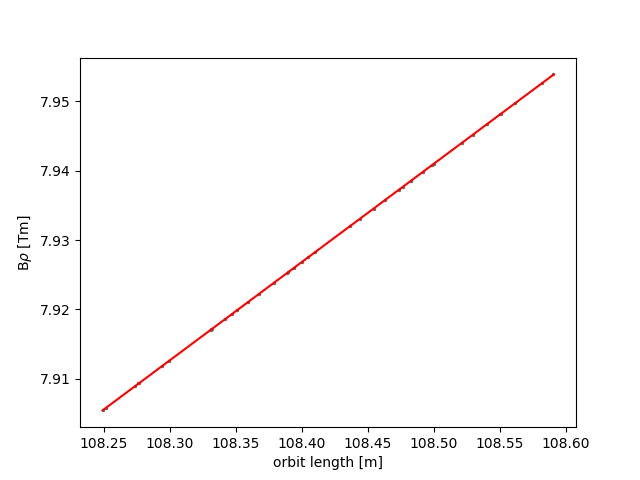

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit 
import pandas as pd

%matplotlib ipympl

# fitting Brho-L curve
def linear_func(x, a, b):
    return a*x + b

linear_para, linear_pcov = curve_fit(linear_func, L_range_init, Brho_range_init)
fitted_Brho = linear_func(fitted_orbit_len, *linear_para)
print('fit: {:.6f} x {:.6f}'.format(*linear_para))
print('estimated Brho = {:.6f} [Tm]'.format(fitted_Brho))

fig, ax = plt.subplots()
ax.scatter(L_range_init, Brho_range_init, s=2, color='dimgray')
ax.plot(L_range_init, linear_func(L_range_init, *linear_para), color='red')
ax.set_xlabel("orbit length [m]")
ax.set_ylabel(r"B$\rho$ [Tm]")
plt.show()


## overlap the iid result with spectrum


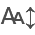

iid: initial...
iid: initial complete


In [6]:
from iid_isochronous_Schottky import IID
import pandas as pd
import itables
itables.init_notebook_mode()

delta_Brho_over_Brho = 0.2 #  [%]
weight_min = 100000

iid = IID(file_folder+lise_file, cen_freq, span, win_len, gamma_t, fitted_orbit_len, delta_Brho_over_Brho, 0.5)
iid.calibrate_Brho(fitted_Brho)
result = iid.cur.execute("SELECT ION, ELEMENT, N, Z, ISOMERIC, PEAKLOC, PEAKSIG, HARMONIC, REVFREQ, HALFLIFE, YIELD, TYPE, WEIGHT, PEAKMAX, SOURCE FROM ISOCHRONOUSION WHERE WEIGHT>=? ORDER BY YIELD DESC", (weight_min,)).fetchall()
data = {
                'ion': ['{:}({:})+'.format(item[0], item[4]) for item in result],
                'element': [item[1] for item in result],
                'N': [item[2] for item in result],
                'Z': [item[3] for item in result],
                'peak_loc': [item[5] + cen_freq*1e3 for item in result],
                'peak_sig': [item[6] for item in result],
                'harmonic': [item[7] for item in result],
                'rev_freq': [item[8] for item in result],
                'half_life': [item[9] for item in result],
                'yield': [item[10] for item in result],
                'type': [item[11] for item in result],
                'weight': [item[12] for item in result],
                'peak_max': [item[13] for item in result],
                'source': [item[14] for item in result],
                }

df = pd.DataFrame(data)
# show the simulated result by an interactive dataframe
itables.show(df) 

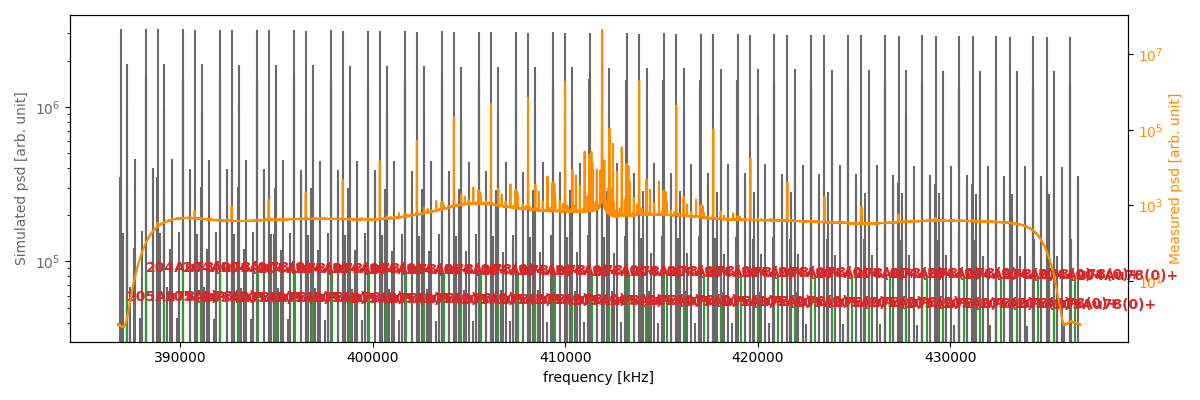

In [7]:
fig, ax2 = plt.subplots(figsize=(12,4))
ax1 = ax2.twinx()  # instantiate a second Axes that shares the same x-axis

color_1 = 'darkorange'
ax2.set_xlabel("frequency [kHz]")
ax1.set_ylabel('Measured psd [arb. unit]', color=color_1)
ax1.semilogy(frequencies, _psd, color=color_1)
ax1.tick_params(axis='y', labelcolor=color_1)

color_2 = 'dimgray'
for peak_area, peak_sig, peak_loc, ion_name, ion_source in zip(data['weight'], data['peak_sig'], data['peak_loc'], data['ion'], data['source']):
    if ion_source == 'estimated':
        ax2.semilogy([peak_loc, peak_loc],[0, peak_area/np.sqrt(2*np.pi)/peak_sig], color='tab:green')
        ax2.annotate(ion_name, xy=(peak_loc, peak_area/np.sqrt(2*np.pi)/peak_sig), xycoords='data', weight='bold', color='tab:red')
    else:
        ax2.semilogy([peak_loc, peak_loc],[0, peak_area/np.sqrt(2*np.pi)/peak_sig], color=color_2)
        #ax2.annotate(ion_name, xy=(peak_loc, peak_area/np.sqrt(2*np.pi)/peak_sig), xycoords='data', color=color_2)
ax2.tick_params(axis='y', labelcolor=color_2)
ax2.set_ylabel('Simulated psd [arb. unit]', color=color_2)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [9]:
sw_0.display_iidResult(fitted_Brho, fitted_orbit_len, 'bestBrhoC')

peakloc -22928.219999999972: 208Pb79(0), 202
peakloc -21003.349999999977: 208Pb79(0), 203
peakloc -19078.45000000001: 208Pb79(0), 204
peakloc -17153.530000000028: 208Pb79(0), 205
peakloc -15228.650000000023: 208Pb79(0), 206
peakloc -14244.469999999972: not in .lpp files
peakloc -13303.75: 208Pb79(0), 207
peakloc -12935.280000000028: 205Hg78(0), 207
peakloc -12741.469999999972: not in .lpp files
peakloc -12315.0: not in .lpp files
peakloc -12014.409999999974: 206Tl78(0), 208
peakloc -11939.630000000005: not in .lpp files
peakloc -11928.950000000012: 198Ir75(0), 208
peakloc -11378.849999999977: 208Pb79(0), 208
peakloc -11008.849999999977: 205Hg78(0), 208
peakloc -10816.590000000026: not in .lpp files
peakloc -10626.590000000026: 202Au77(0), 208
peakloc -10385.5: 201Pt76(1), 209
peakloc -10092.549999999988: 206Tl78(0), 209
peakloc -10018.530000000028: not in .lpp files
peakloc -10014.719999999972: not in .lpp files
peakloc -10002.530000000028: 204Au78(0), 208
peakloc -9997.969999999972: n

,peakloc,peak_height,peak_width,ion,isomeric,harmonic
0,388814.03,69.908051,1.580885,208Pb79,0,202
1,390738.90,260.714122,1.485657,208Pb79,0,203
2,392663.80,551.213926,1.392631,208Pb79,0,204
3,394588.72,989.175367,1.374925,208Pb79,0,205
4,396513.60,1738.064700,1.456710,208Pb79,0,206
...,...,...,...,...,...,...
419,425385.50,591.835589,1.614431,208Pb79,0,221
420,427310.40,216.993189,1.546370,208Pb79,0,222
421,429235.28,75.583004,1.516184,208Pb79,0,223
422,431160.20,34.963345,1.589590,208Pb79,0,224
